<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/Scratchpad_bo_or_not_mine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
%%capture
pip install fiftyone==1.8.0

In [14]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [15]:
import os
from google.colab import userdata
import kagglehub

# This is set up as an environment variable, it's alive in memory
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# to download the data, we specify the name of the user who published it and the name of the dataset
download_path = kagglehub.dataset_download('andandand/presidential-dog')

Using Colab cache for faster access to the 'presidential-dog' dataset.


In [4]:
download_path

'/root/.cache/kagglehub/datasets/andandand/presidential-dog/versions/1'

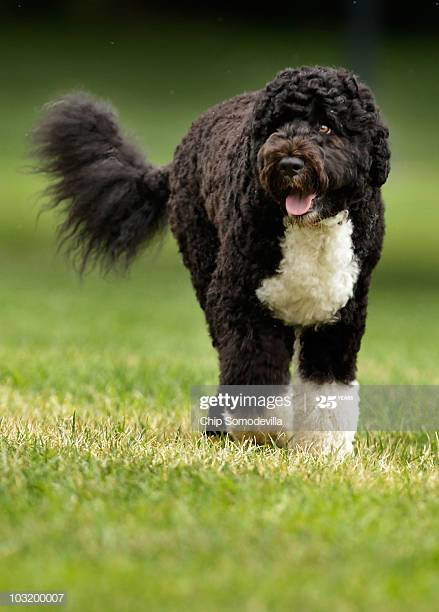

In [19]:
from PIL import Image
pil_imag = Image.open('/kaggle/input/presidential-dog/presidential_dog/test/bo/bo_20.jpg')
pil_imag

In [20]:
from torchvision.models import VGG16_Weights
pretrained_weights = VGG16_Weights.IMAGENET1K_V1
dir(pretrained_weights)

['__class__',
 '__doc__',
 '__eq__',
 '__hash__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

In [21]:
original_transformation = pretrained_weights.transforms()
original_transformation

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [22]:
imag_tensor_imagenet_scaled = original_transformation(pil_imag)
imag_tensor_imagenet_scaled.shape

torch.Size([3, 224, 224])

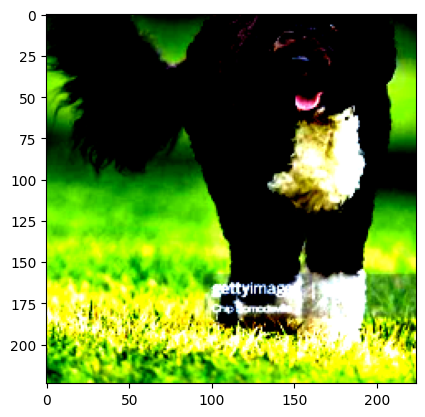

In [23]:
import matplotlib.pyplot as plt
plt.imshow(imag_tensor_imagenet_scaled.permute(1, 2, 0))

In [24]:
pretrained_weights.meta

{'min_size': (32, 32),
 'categories': ['tench',
  'goldfish',
  'great white shark',
  'tiger shark',
  'hammerhead',
  'electric ray',
  'stingray',
  'cock',
  'hen',
  'ostrich',
  'brambling',
  'goldfinch',
  'house finch',
  'junco',
  'indigo bunting',
  'robin',
  'bulbul',
  'jay',
  'magpie',
  'chickadee',
  'water ouzel',
  'kite',
  'bald eagle',
  'vulture',
  'great grey owl',
  'European fire salamander',
  'common newt',
  'eft',
  'spotted salamander',
  'axolotl',
  'bullfrog',
  'tree frog',
  'tailed frog',
  'loggerhead',
  'leatherback turtle',
  'mud turtle',
  'terrapin',
  'box turtle',
  'banded gecko',
  'common iguana',
  'American chameleon',
  'whiptail',
  'agama',
  'frilled lizard',
  'alligator lizard',
  'Gila monster',
  'green lizard',
  'African chameleon',
  'Komodo dragon',
  'African crocodile',
  'American alligator',
  'triceratops',
  'thunder snake',
  'ringneck snake',
  'hognose snake',
  'green snake',
  'king snake',
  'garter snake',
 

In [27]:
from torchvision.models import vgg16, VGG16_Weights

# Loading a pre-trained VGG16 model
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [28]:
# Here we inspect the first layer of features
first_layer = model.features[0]
first_layer

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [29]:
first_layer.weight

Parameter containing:
tensor([[[[-5.5373e-01,  1.4270e-01,  5.2896e-01],
          [-5.8312e-01,  3.5655e-01,  7.6566e-01],
          [-6.9022e-01, -4.8019e-02,  4.8409e-01]],

         [[ 1.7548e-01,  9.8630e-03, -8.1413e-02],
          [ 4.4089e-02, -7.0323e-02, -2.6035e-01],
          [ 1.3239e-01, -1.7279e-01, -1.3226e-01]],

         [[ 3.1303e-01, -1.6591e-01, -4.2752e-01],
          [ 4.7519e-01, -8.2677e-02, -4.8700e-01],
          [ 6.3203e-01,  1.9308e-02, -2.7753e-01]]],


        [[[ 2.3254e-01,  1.2666e-01,  1.8605e-01],
          [-4.2805e-01, -2.4349e-01,  2.4628e-01],
          [-2.5066e-01,  1.4177e-01, -5.4864e-03]],

         [[-1.4076e-01, -2.1903e-01,  1.5041e-01],
          [-8.4127e-01, -3.5176e-01,  5.6398e-01],
          [-2.4194e-01,  5.1928e-01,  5.3915e-01]],

         [[-3.1432e-01, -3.7048e-01, -1.3094e-01],
          [-4.7144e-01, -1.5503e-01,  3.4589e-01],
          [ 5.4384e-02,  5.8683e-01,  4.9580e-01]]],


        [[[ 1.7715e-01,  5.2149e-01,  9.8740

In [30]:
# Why doesn't this work?
#first_layer(pil_imag)
output_first_convolutions = first_layer(imag_tensor_imagenet_scaled)
output_first_convolutions.shape

torch.Size([64, 224, 224])

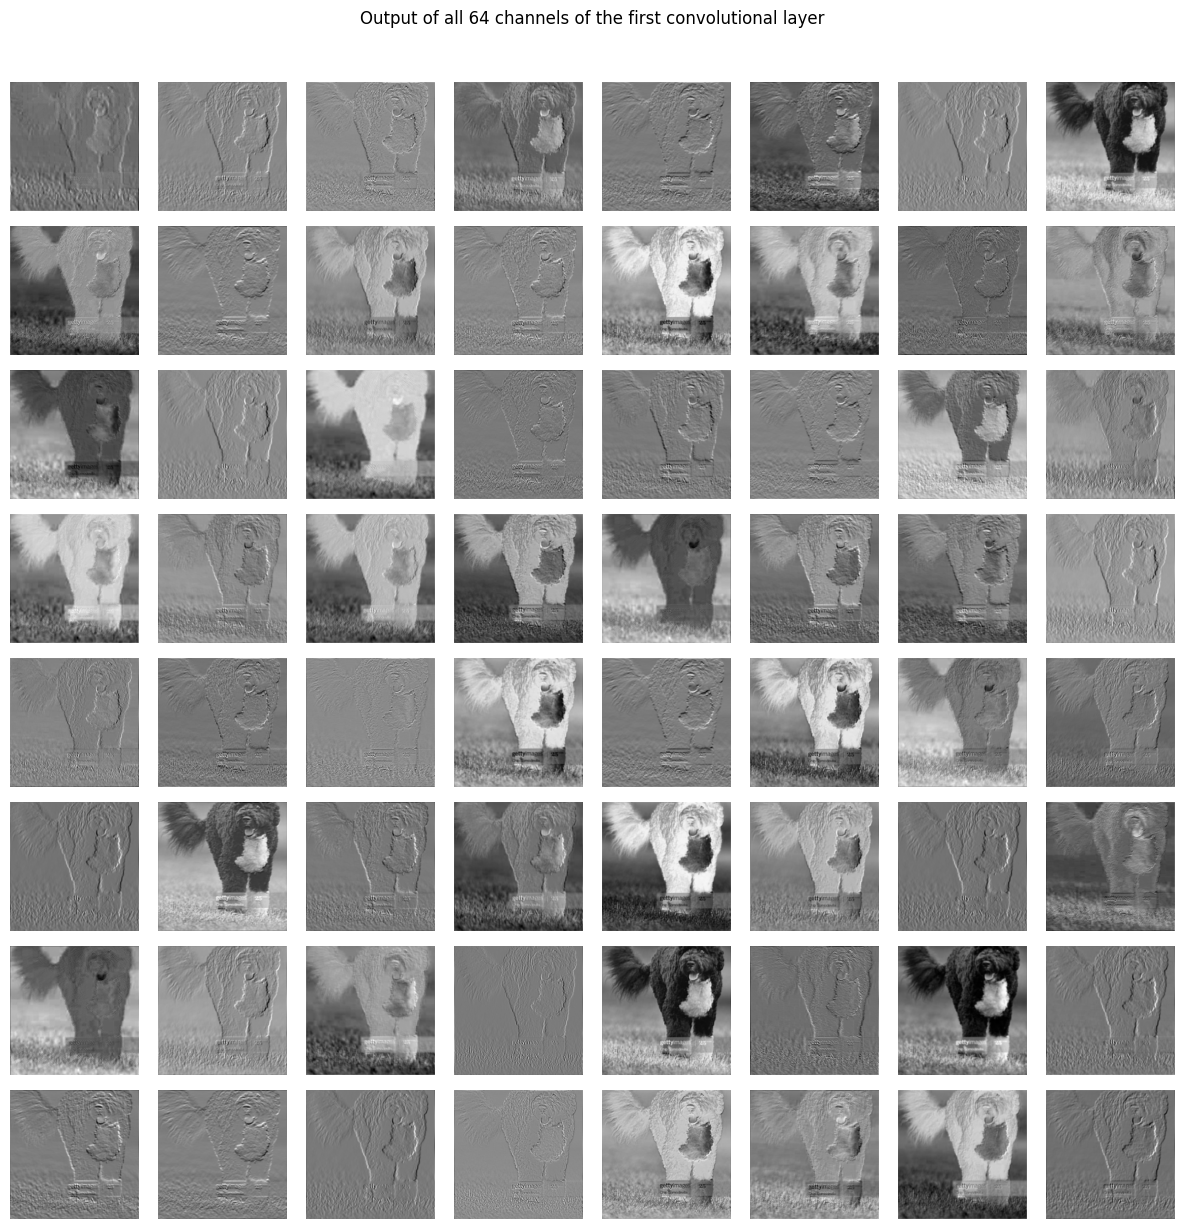

In [31]:
num_channels = output_first_convolutions.shape[0]
fig, axes = plt.subplots(8, 8, figsize=(12, 12))

for i in range(num_channels):
    row = i // 8
    col = i % 8
    axes[row, col].imshow(output_first_convolutions[i, :, :].detach().numpy(), cmap='gray')
    axes[row, col].axis('off')

plt.suptitle('Output of all 64 channels of the first convolutional layer', y=1.02)
plt.tight_layout()
plt.show()

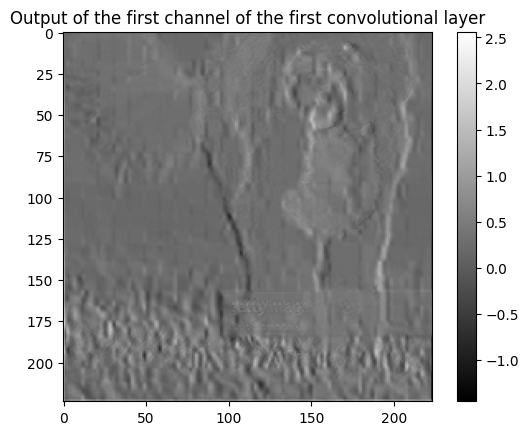

In [32]:
plt.imshow(output_first_convolutions[0, :, :].detach().numpy(), cmap='gray')
plt.title('Output of the first channel of the first convolutional layer')
plt.colorbar()
plt.show()

## Run image into the full convolutional base of the model

In [33]:
# Why do we specify singleton dimensions?
# When training, we want to specify the batch size
# which is the number of samples that we show to the model before computing the loss
# and updating the weights (during training)
imag_tensor_imagenet_scaled.unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [34]:
imag_tensor_imagenet_scaled.unsqueeze(0).squeeze().shape

torch.Size([3, 224, 224])

In [35]:
output_conv_base = model.features(imag_tensor_imagenet_scaled)
output_conv_base.shape

torch.Size([512, 7, 7])

## Intuition on Class Activation Mapping

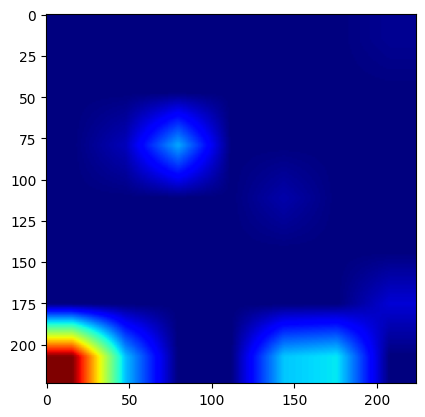

In [36]:
import torchvision.transforms.v2 as transforms
resize = transforms.Resize(224)
resized_output_conv_base = resize(output_conv_base)
plt.imshow(resized_output_conv_base[0, :, :].detach().numpy(),cmap='jet');

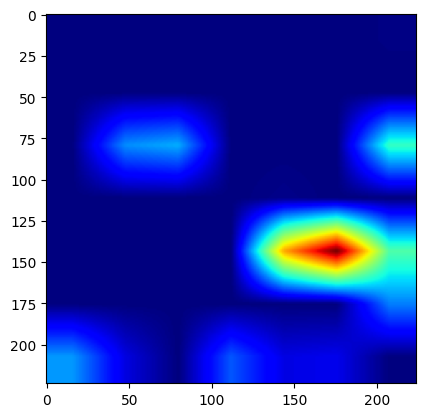

In [37]:
# For the neural network, the weighted sum comes from the weights of the final layer
weighted_sum = resized_output_conv_base[0, :, :] * .2 + resized_output_conv_base[1, :, :] * .7
plt.imshow(weighted_sum.detach(), cmap='jet');

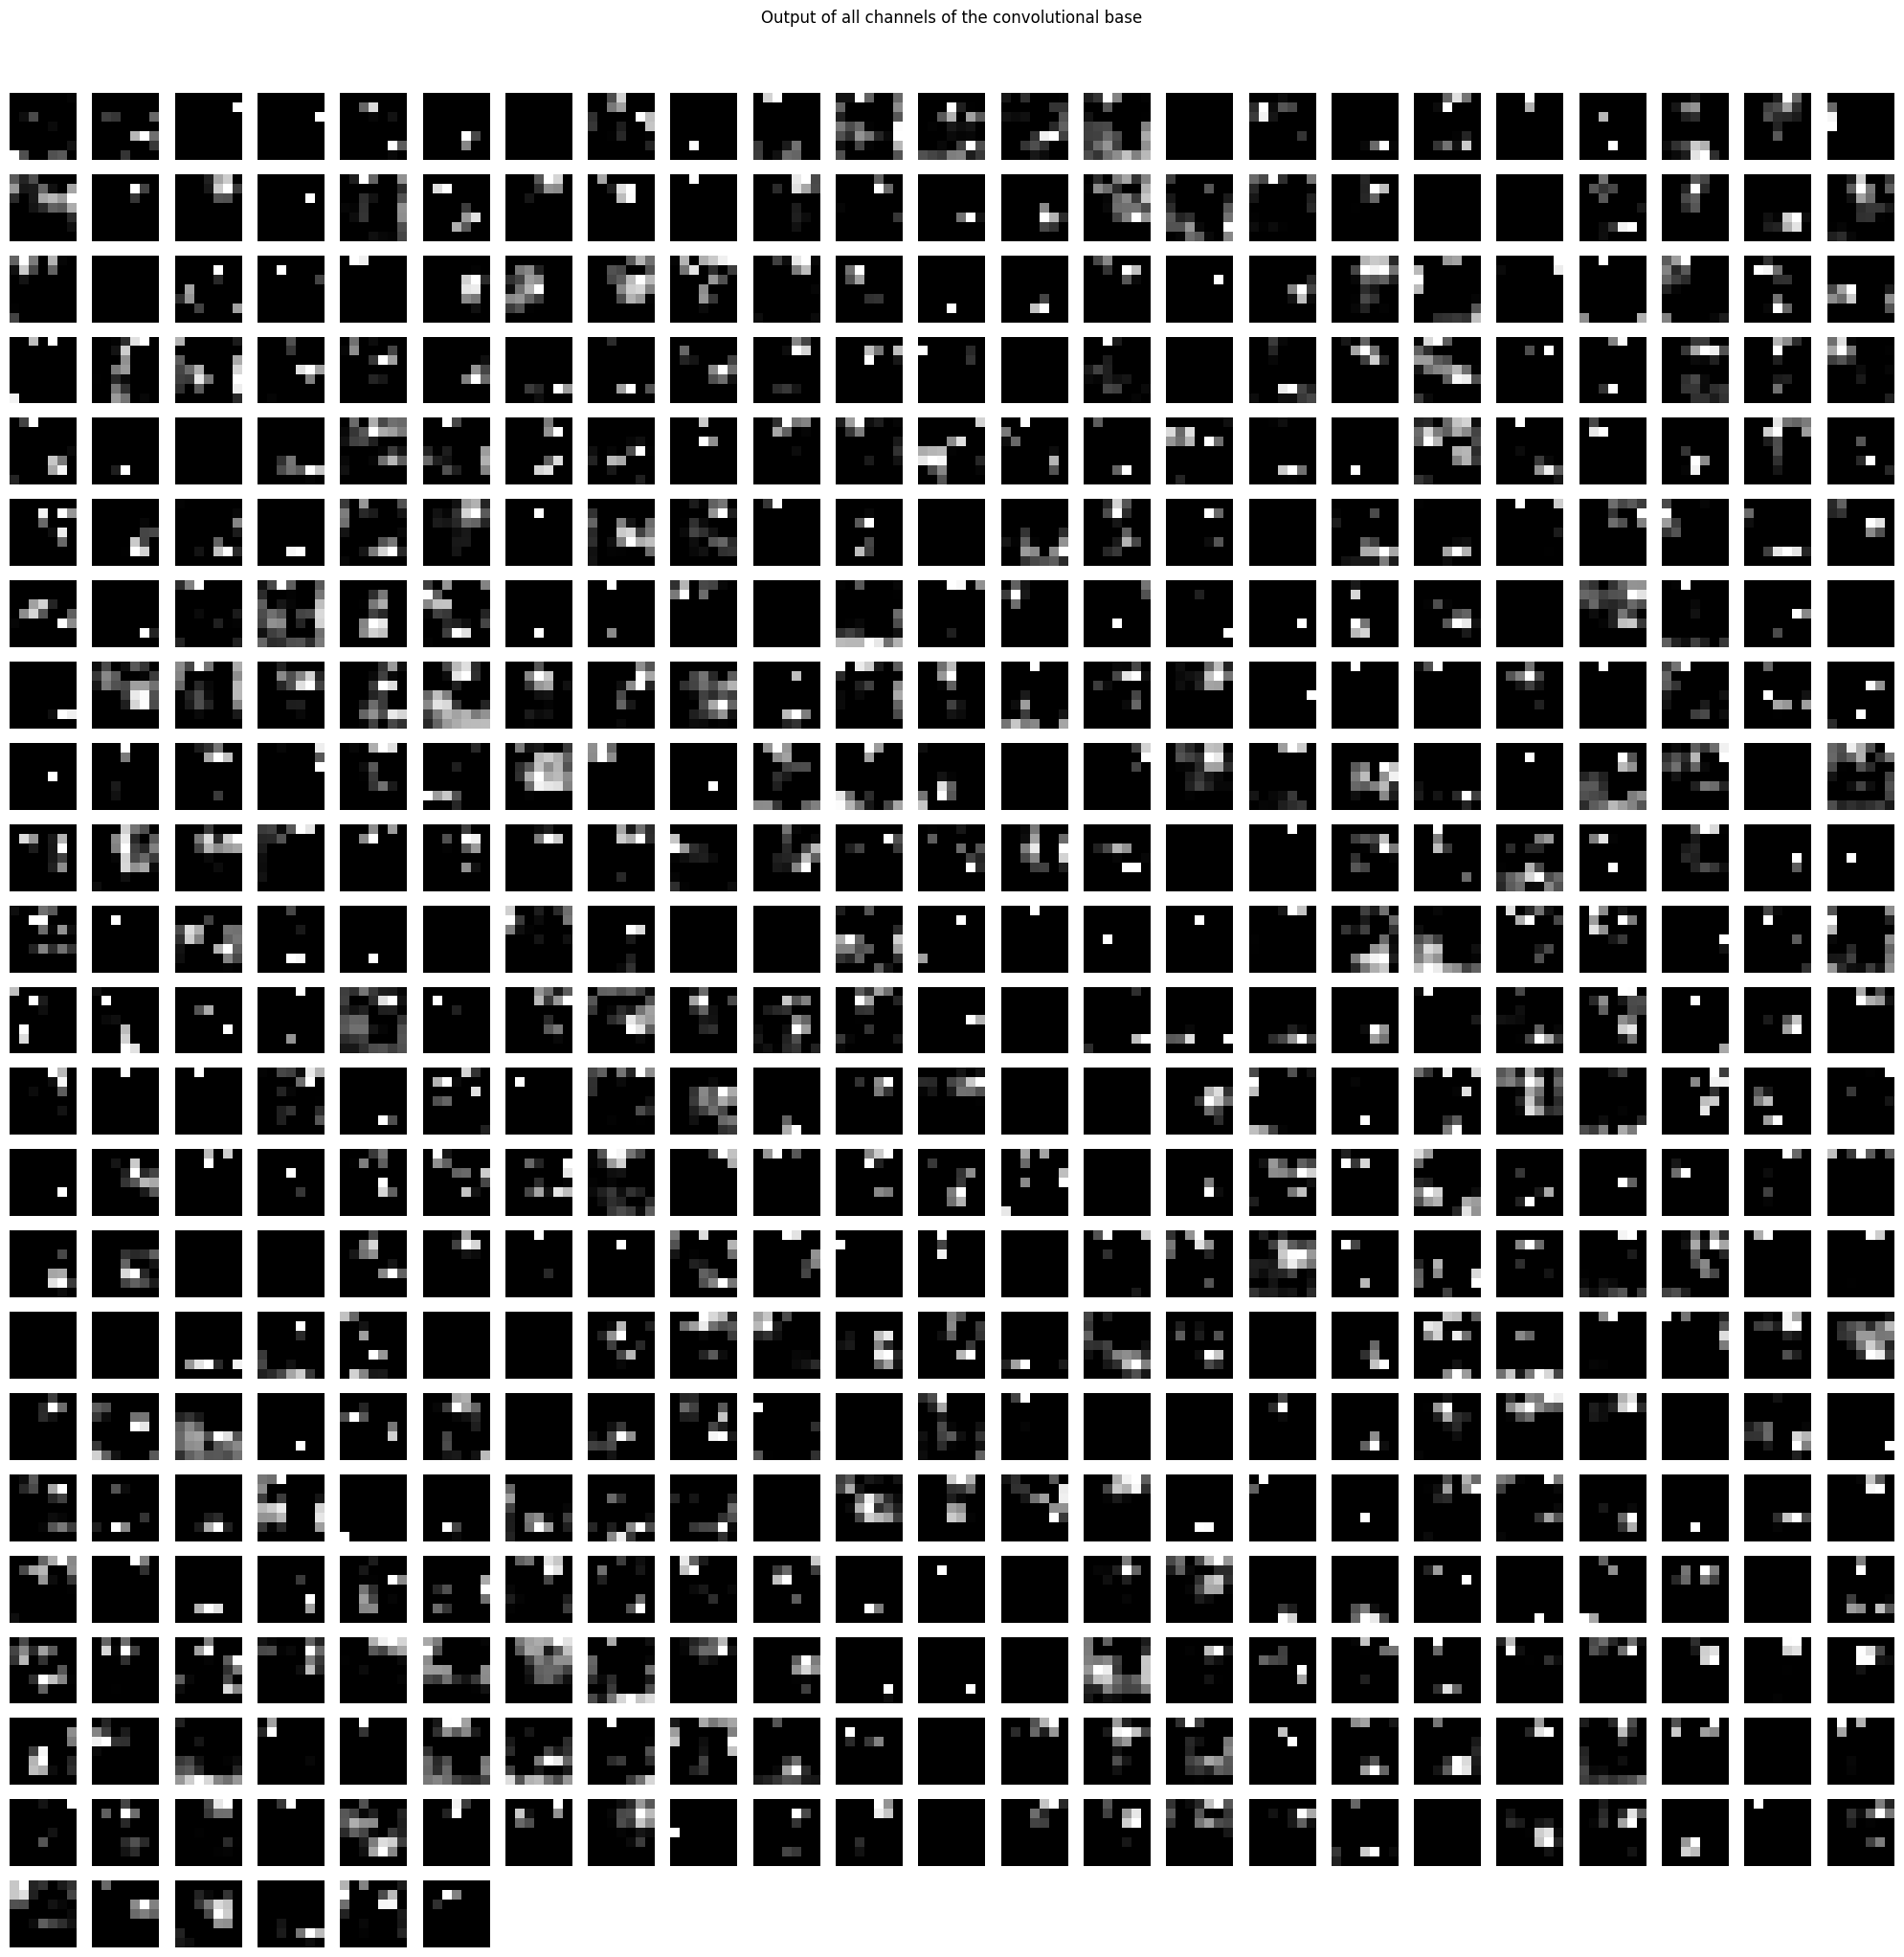

In [38]:
num_channels_conv_base = output_conv_base.shape[0]
# Determine the grind size, aiming for a roughly square layout
grid_size = int(num_channels_conv_base**0.5) + 1
fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))

for i in range(num_channels_conv_base):
    row = i // grid_size
    col = i % grid_size
    axes[row, col].imshow(output_conv_base[i, :, :].detach().numpy(), cmap='gray')
    axes[row, col].axis('off')

# Turn off any unused subplots
for j in range(num_channels_conv_base, grid_size * grid_size):
    row = j // grid_size
    col = j % grid_size
    axes[row, col].axis('off')

plt.suptitle('Output of all channels of the convolutional base', y=1.02)
plt.tight_layout()
plt.show()

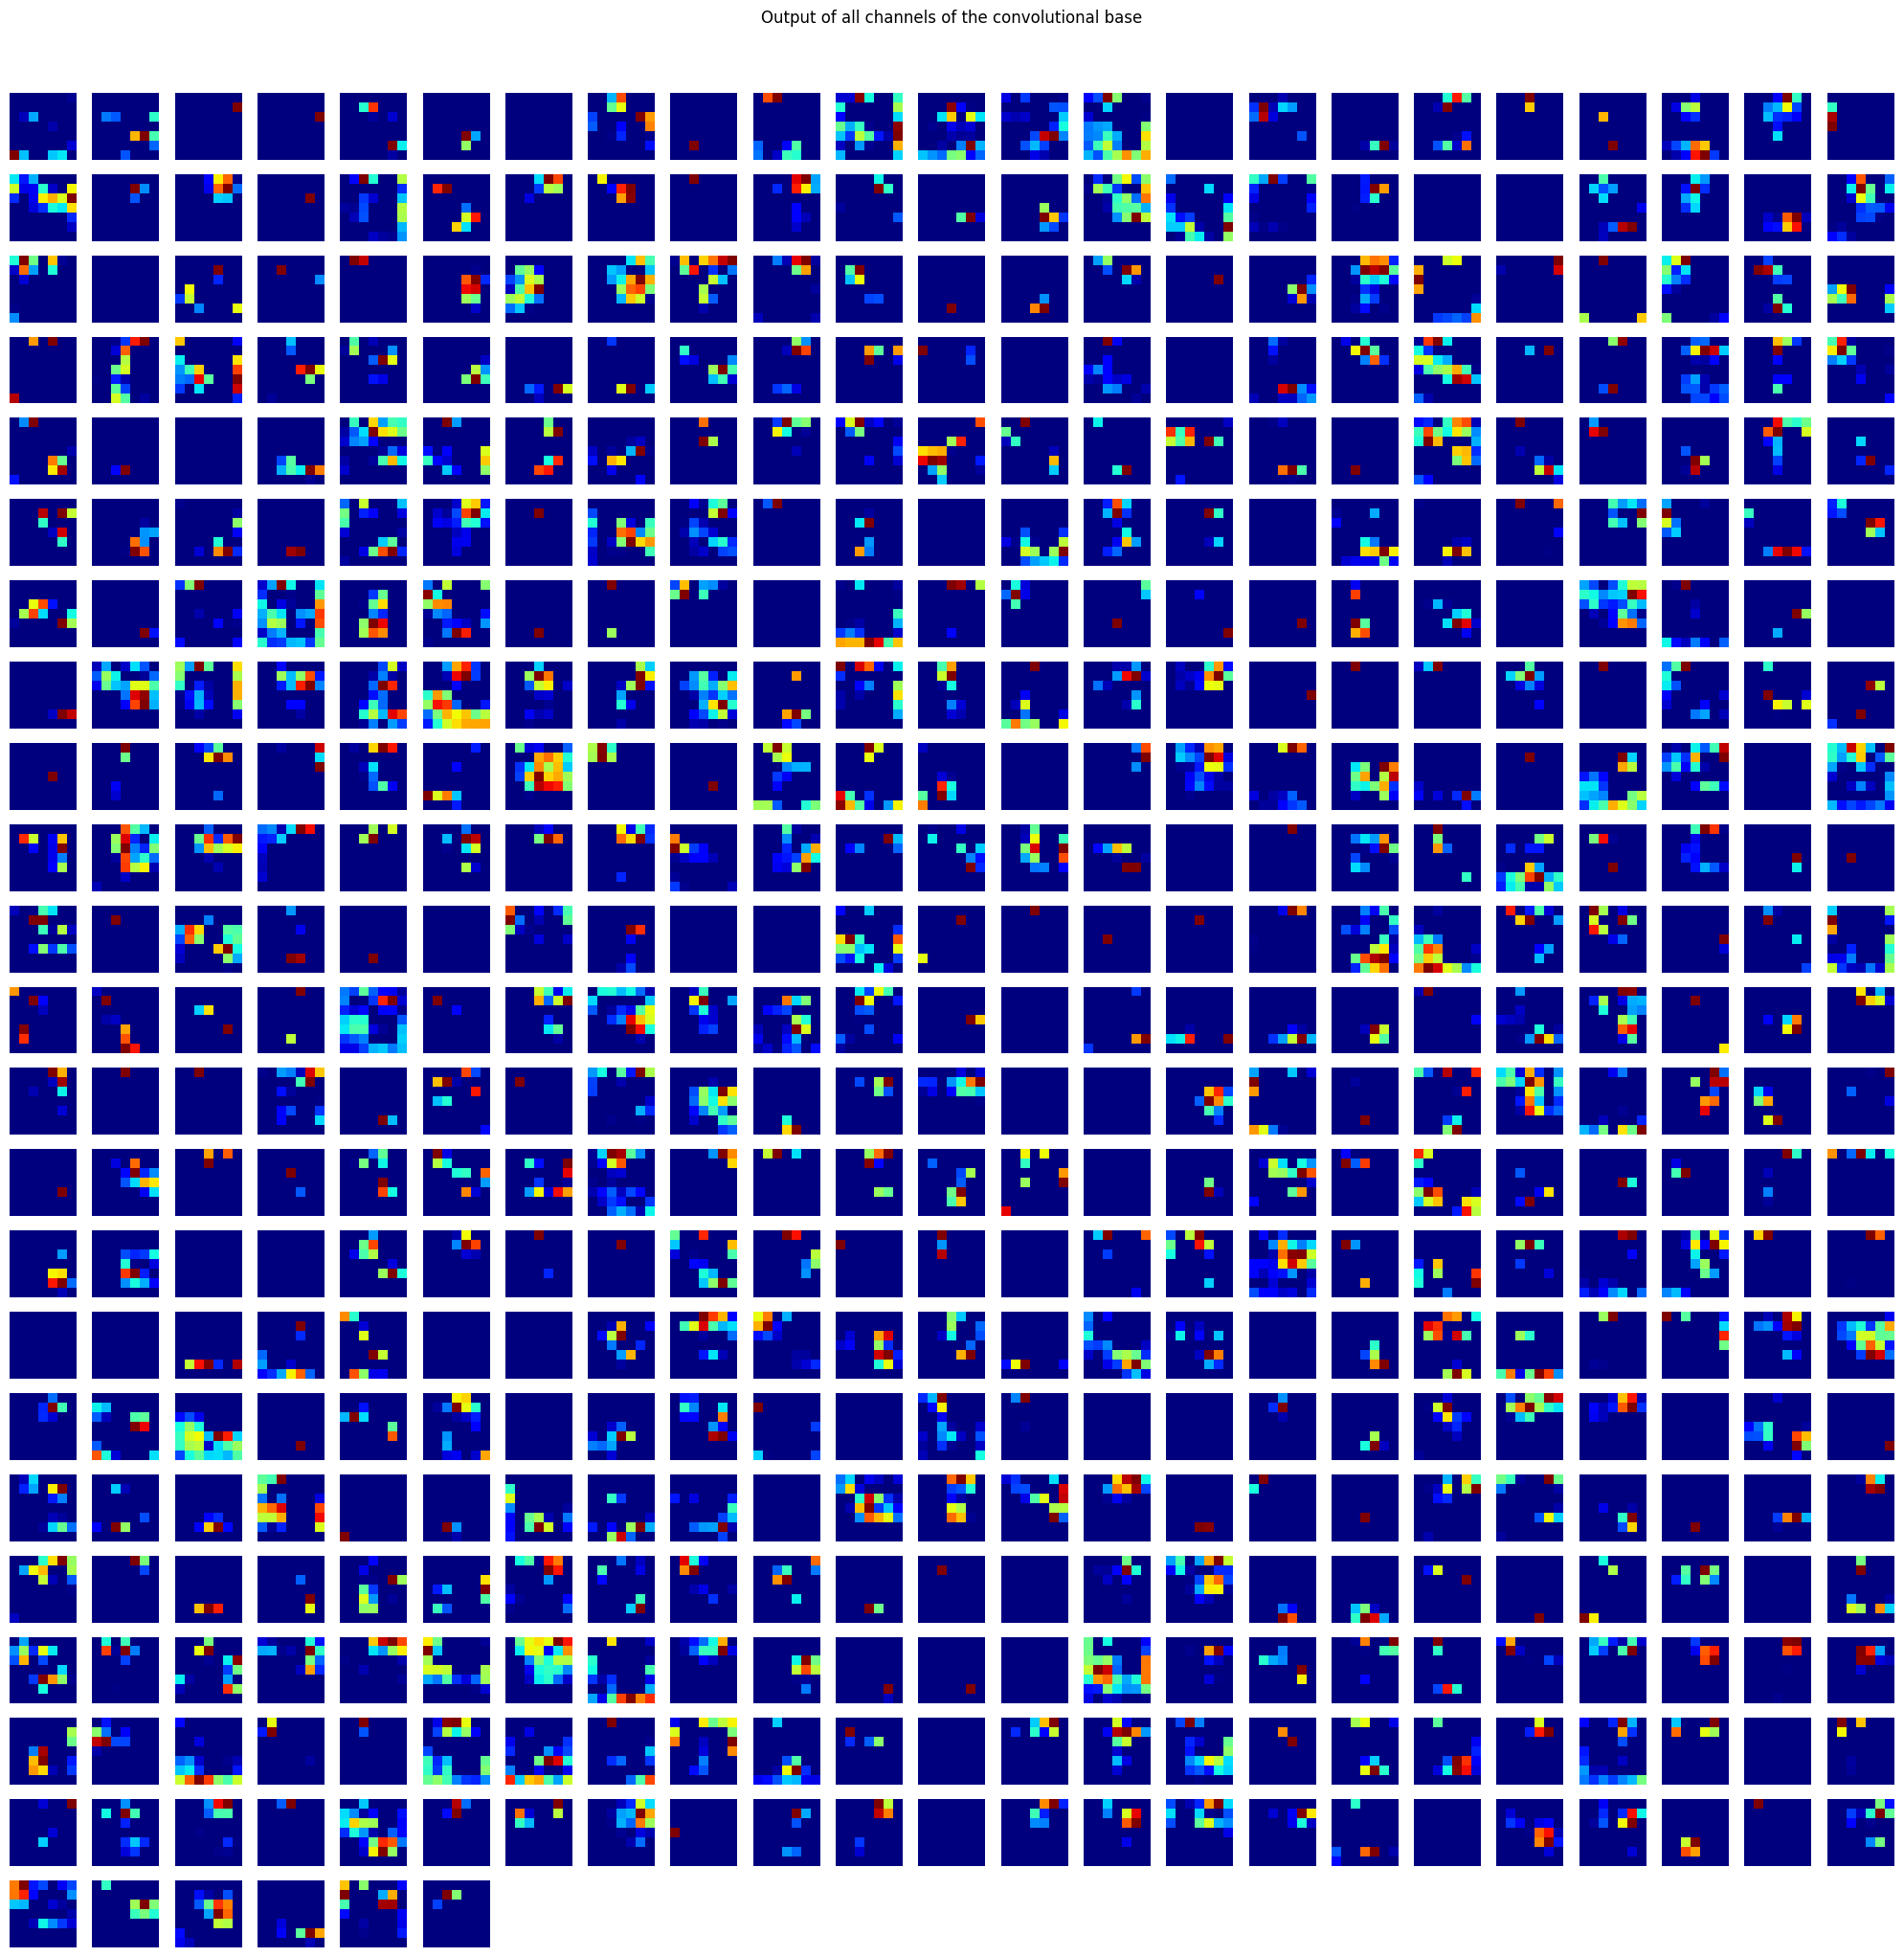

In [39]:
num_channels_conv_base = output_conv_base.shape[0]
# Determine the grid size, aiming for a roughly square layout
grid_size = int(num_channels_conv_base**0.5) + 1
fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))
for i in range(num_channels_conv_base):
    row = i // grid_size
    col = i % grid_size
    axes[row, col].imshow(output_conv_base[i, :, :].detach().numpy(), cmap='jet')
    axes[row, col].axis('off')

# Turn off any unused subplots
for j in range(num_channels_conv_base, grid_size * grid_size):
    row = j // grid_size
    col = j % grid_size
    axes[row, col].axis('off')


plt.suptitle('Output of all channels of the convolutional base', y=1.02)
plt.tight_layout()
plt.show()

In [40]:
model.avgpool

AdaptiveAvgPool2d(output_size=(7, 7))

In [41]:
import torch.nn as nn
avg_pool_flattening = nn. AdaptiveAvgPool2d(output_size=(1, 1))

In [42]:
output_conv_base

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0316],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0890, 0.5019,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.1310],
         [1.7209, 0.5398, 0.0000,  ..., 0.5518, 0.6097, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.4473, 0.3875,  ..., 0.0000, 0.0000, 0.7389],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 1.3101, 1.8240, 0.7972],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.4096],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.7917],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.

In [43]:
output_gap = model.avgpool(output_conv_base)
output_gap.shape

torch.Size([512, 7, 7])

In [44]:
average_per_filter = avg_pool_flattening(output_conv_base)
average_per_filter.shape

torch.Size([512, 1, 1])

In [45]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [46]:
7 * 7 * 512

25088

In [47]:
from torchvision.models import resnet18

resnet_model = resnet18()
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Create a FiftyOne dataset

In [54]:
from pathlib import Path
train_data_path = Path('/kaggle/input/presidential-dog/presidential_dog/train')
test_data_path = Path('/kaggle/input/presidential-dog/presidential_dog/test')
train_data_path, test_data_path

(PosixPath('/kaggle/input/presidential-dog/presidential_dog/train'),
 PosixPath('/kaggle/input/presidential-dog/presidential_dog/test'))

In [56]:
import fiftyone as fo

# Replace 'dataset_name' with the actual name of the dataset you want to delete
dataset_name = 'bo-training-dataset'

if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)
    print(f"Dataset '{dataset_name}' deleted successfully.")

print(f'Created {dataset_name}')

training_dataset = fo.Dataset.from_dir(
    dataset_dir = str(train_data_path),
    dataset_type = fo.types.ImageClassificationDirectoryTree,
    name=dataset_name
)
import fiftyone.utils.random as four
# split the training_dataset into train and validation
four.random_split(training_dataset,
                  {'train': 0.75, 'validation':0.25},
                  seed=51)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information


Created bo-training-dataset
 100% |█████████████████| 142/142 [94.5ms elapsed, 0s remaining, 1.5K samples/s]   


INFO:eta.core.utils: 100% |█████████████████| 142/142 [94.5ms elapsed, 0s remaining, 1.5K samples/s]   


In [57]:
training_dataset.count_sample_tags()

{'validation': 36, 'train': 106}

In [58]:
training_dataset

Name:        bo-training-dataset
Media type:  image
Num samples: 142
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)

In [59]:
testing_dataset = fo.Dataset.from_dir(
    dataset_dir = str(test_data_path),
    dataset_type = fo.types.ImageClassificationDirectoryTree,
    name='bo-testing-dataset'
)

 100% |███████████████████| 30/30 [32.6ms elapsed, 0s remaining, 919.8 samples/s]     


INFO:eta.core.utils: 100% |███████████████████| 30/30 [32.6ms elapsed, 0s remaining, 919.8 samples/s]     


In [60]:
testing_dataset.tag_samples('test')

In [61]:
# merge train and test datasets
import fiftyone as fo

# Replace 'dataset_name' with the actual name of the dataset you want to delete
dataset_name = 'bo-dataset'

if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)
    print(f"Dataset '{dataset_name}' deleted successfully.")

print(f'Created {dataset_name}')
bo_dataset =fo.Dataset(dataset_name)
bo_dataset.merge_samples(training_dataset)
bo_dataset.merge_samples(testing_dataset)

Created bo-dataset


In [62]:
bo_dataset

Name:        bo-dataset
Media type:  image
Num samples: 172
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)

In [63]:
bo_dataset.count_sample_tags()

{'validation': 36, 'train': 106, 'test': 30}

In [64]:
# compute the metadata for the whole dataset
bo_dataset.compute_metadata()

Computing metadata...


INFO:fiftyone.core.metadata:Computing metadata...


 100% |█████████████████| 172/172 [402.2ms elapsed, 0s remaining, 427.7 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 172/172 [402.2ms elapsed, 0s remaining, 427.7 samples/s]      


In [65]:
session = fo.launch_app(bo_dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.



Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.8.0

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



INFO:fiftyone.core.session.session:
Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.8.0

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Discord community 🚀🚀🚀
|  https://community.voxel51.com/
|



https://5151-gpu-t4-s-17bdwgps2yzjy-a.us-west4-0.prod.colab.dev?polling=true


In [66]:
session.refresh()
print(session.url)

https://5151-gpu-t4-s-17bdwgps2yzjy-a.us-west4-0.prod.colab.dev?polling=true


## Load the VGG16 model into FiftyOne

In [67]:
import fiftyone.zoo as foz

fo_model = foz.load_zoo_model('vgg16-imagenet-torch')
fo_model

INFO:fiftyone.core.models:Downloading model from 'https://download.pytorch.org/models/vgg16-397923af.pth'...


 100% |██████|    4.1Gb/4.1Gb [3.4s elapsed, 0s remaining, 694.6Mb/s]      


INFO:eta.core.utils: 100% |██████|    4.1Gb/4.1Gb [3.4s elapsed, 0s remaining, 694.6Mb/s]      


In [68]:
fo_model._model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Compute embeddings

In [73]:
bo_dataset.compute_embeddings(model=fo_model,
                              embeddings_field='vgg16-imagenet-embeddings')

 100% |█████████████████| 172/172 [9.9s elapsed, 0s remaining, 17.2 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 172/172 [9.9s elapsed, 0s remaining, 17.2 samples/s]      


In [74]:
embeddings = bo_dataset.values('vgg16-imagenet-embeddings')
embeddings[0].shape

(4096,)

In [76]:
len(embeddings)

172

In [78]:
import fiftyone.brain as fob

pca_visualization = fob.compute_visualization(bo_dataset,
                                                method='pca',
                                                brain_key='vgg_pca')

INFO:fiftyone.core.models:Downloading model from 'https://download.pytorch.org/models/mobilenet_v2-b0353104.pth'...


 100% |████|  108.4Mb/108.4Mb [65.0ms elapsed, 0s remaining, 1.6Gb/s]   


INFO:eta.core.utils: 100% |████|  108.4Mb/108.4Mb [65.0ms elapsed, 0s remaining, 1.6Gb/s]   


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]


...

INFO:fiftyone.brain.internal.core.utils:Computing embeddings...


 100% |█████████████████| 172/172 [8.0s elapsed, 0s remaining, 23.9 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 172/172 [8.0s elapsed, 0s remaining, 23.9 samples/s]      


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


In [80]:
session.refresh()
print(session.url)

https://5151-gpu-t4-s-17bdwgps2yzjy-a.us-west4-0.prod.colab.dev?polling=true


## Compute a similarity index

In [97]:
fob.compute_similarity(bo_dataset,
                       embeddings='vgg16-imagenet-embeddings',
                       brain_key='vgg16_imagenet_similarity',
                       backend='sklearn',
                       metric='cosine')

ValueError: Brain method run with key 'vgg16_imagenet_similarity' already exists

In [98]:
# We take a sample and use it to inspect its neighborhood.
# You can change the seed to select a different sample
#a_sample = [sample for sample in bo_dataset.take(1, seed=5151)][0]
a_sample = bo_dataset.first()
a_sample

<Sample: {
    'id': '6900e2cf9bcf9946f19d93de',
    'media_type': 'image',
    'filepath': '/kaggle/input/presidential-dog/presidential_dog/train/bo/.ipynb_checkpoints/bo_10-checkpoint.jpg',
    'tags': ['train'],
    'metadata': <ImageMetadata: {
        'size_bytes': 52803,
        'mime_type': 'image/jpeg',
        'width': 394,
        'height': 400,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2025, 10, 28, 15, 35, 43, 791000),
    'last_modified_at': datetime.datetime(2025, 10, 28, 15, 39, 52, 567000),
    'ground_truth': <Classification: {
        'id': '6900e2cbf38d8244078c7100',
        'tags': [],
        'label': 'bo',
        'confidence': None,
        'logits': None,
    }>,
    'vgg16-imagenet-embeddings': array([0., 0., 0., ..., 0., 0., 0.]),
}>

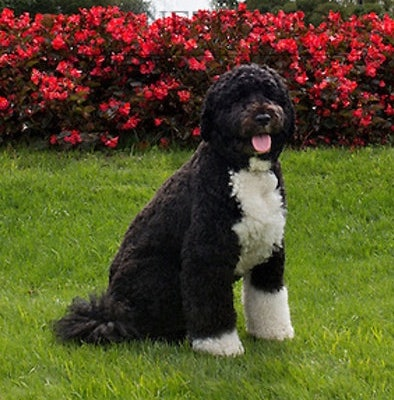

In [99]:
# We can access any sample's filepath
Image.open(a_sample.filepath)

In [101]:
# Use the dataset's query_similar method
similar_view = bo_dataset.sort_by_similarity(
  a_sample.id,
  brain_key="vgg16_imagenet_similarity",
  k=5,  # Return top k similar images
  reverse=False  # Most similar first
)

# We save the view so that we can retrieve it later
bo_dataset.save_view('most_similar_to_sample', similar_view)

ValueError: Saved view 'most_similar_to_sample' already exists

## Creating a fine-tuned model based on the original VGG16 (transfer learning)

In [102]:
# We take the embeddings produced by the original VGG16 model as features
# for a classifier that replaces the final layers of VGG16
# we keep this as illustration only
input_to_fine_tuned_model = nn.Sequential(model.features,
                                          model.avgpool,
                                          nn.Flatten())
input_to_fine_tuned_model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [103]:
# this replaces the last layers of the original vgg16 model
model.classifier = nn.Sequential(nn.Linear(in_features=25088, out_features=4096),
                                 nn.ReLU(),
                                 nn.Linear(in_features=4096, out_features=1),
                                 )
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1